In [5]:
gray = "gray.png"
original = "original.png"
filtered = "filtered.png"
thresh = "thresh.png"

In [6]:
import cv2 
import PIL 
import easyocr

In [7]:
import torch
print(torch.cuda.is_available())  # Should print False


False


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


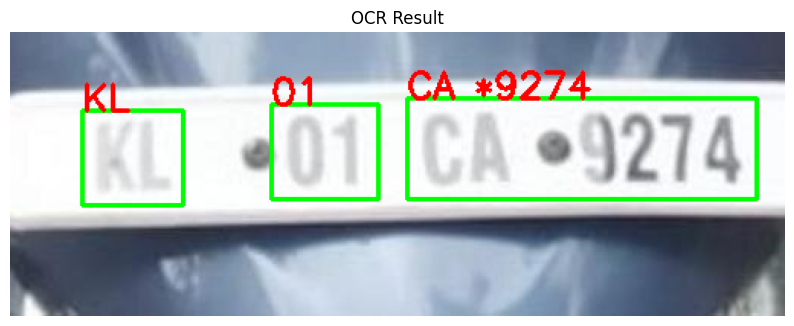

In [23]:
import os
import cv2
import easyocr
from matplotlib import pyplot as plt

# Force CPU-only mode by hiding GPU from all libraries
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Load image
# original = 'path/to/image.jpg'  # Replace this with the actual image path
img = cv2.imread("./img.png")

# Convert BGR to RGB for matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Initialize EasyOCR reader (guaranteed CPU mode)
reader = easyocr.Reader(['en'])

# Perform OCR
result = reader.readtext(img)

# Draw bounding boxes and text
for (bbox, text, prob) in result:
    top_left = tuple(map(int, bbox[0]))
    bottom_right = tuple(map(int, bbox[2]))
    cv2.rectangle(img_rgb, top_left, bottom_right, (0, 255, 0), 2)
    cv2.putText(img_rgb, text, top_left, cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

# Display result using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('OCR Result')
plt.show()


In [24]:
import cv2
import easyocr

# Read the image
img = cv2.imread("./img.png")  # 'original' should be the image file path as a string

# Initialize EasyOCR reader with CPU
reader = easyocr.Reader(['en'], gpu=False)

# Perform OCR
result = reader.readtext(img)

# Display the result
print(result)


Using CPU. Note: This module is much faster with a GPU.


[([[np.int32(47), np.int32(51)], [np.int32(113), np.int32(51)], [np.int32(113), np.int32(113)], [np.int32(47), np.int32(113)]], 'KL', np.float64(0.9408023960218702)), ([[np.int32(171), np.int32(47)], [np.int32(241), np.int32(47)], [np.int32(241), np.int32(109)], [np.int32(171), np.int32(109)]], '01', np.float64(0.5243539532062319)), ([[np.int32(260), np.int32(43)], [np.int32(489), np.int32(43)], [np.int32(489), np.int32(109)], [np.int32(260), np.int32(109)]], 'CA *9274', np.float64(0.3428121405559376))]


In [25]:
from matplotlib import pyplot as plt

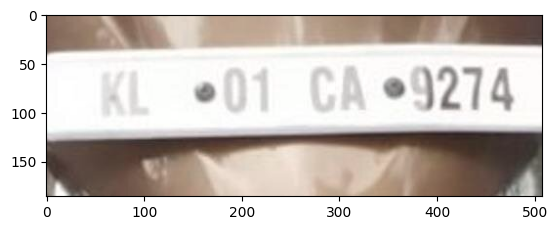

In [26]:
plt.imshow(img)

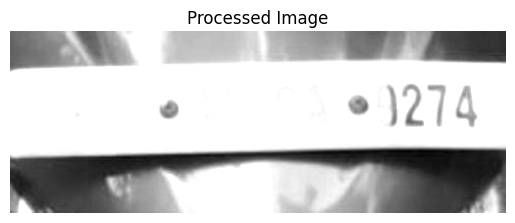

In [28]:
import cv2
import numpy as np

# Load the image (in grayscale for OCR preprocessing)
image = cv2.imread("./img.png", cv2.IMREAD_GRAYSCALE)

# --- Step 1: Brighten the image ---
# Increase brightness by adding a constant to all pixels
bright = cv2.convertScaleAbs(image, alpha=1.2, beta=10)  # beta = brightness

# --- Step 2: Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) ---
# clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# clahe_img = clahe.apply(bright)

import matplotlib.pyplot as plt

plt.imshow(bright, cmap='gray')
plt.title('Processed Image')
plt.axis('off')
plt.show()

[([[np.int32(47), np.int32(51)],
   [np.int32(113), np.int32(51)],
   [np.int32(113), np.int32(113)],
   [np.int32(47), np.int32(113)]],
  'KL',
  np.float64(0.9408023960218702)),
 ([[np.int32(171), np.int32(47)],
   [np.int32(241), np.int32(47)],
   [np.int32(241), np.int32(109)],
   [np.int32(171), np.int32(109)]],
  '01',
  np.float64(0.5243539532062319)),
 ([[np.int32(260), np.int32(43)],
   [np.int32(489), np.int32(43)],
   [np.int32(489), np.int32(109)],
   [np.int32(260), np.int32(109)]],
  'CA *9274',
  np.float64(0.31827897054588666))]

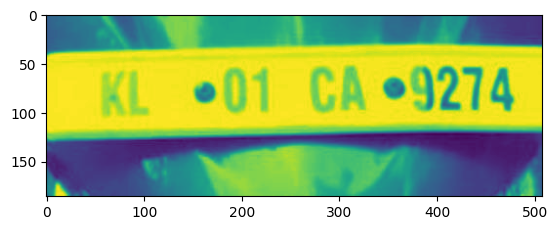

In [29]:
img = cv2.imread("./img.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(img)
reader.readtext(img)

[([[np.int32(377), np.int32(47)],
   [np.int32(487), np.int32(47)],
   [np.int32(487), np.int32(107)],
   [np.int32(377), np.int32(107)]],
  '1274',
  np.float64(0.9773995876312256))]

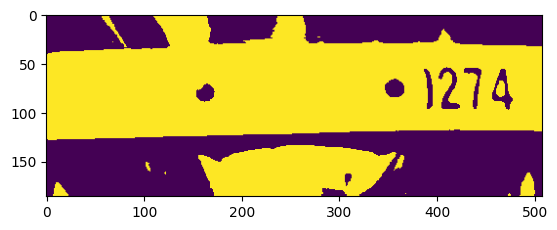

In [ ]:
_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(thresh)
reader.readtext(thresh)

<class 'numpy.ndarray'> uint8 (186, 508)


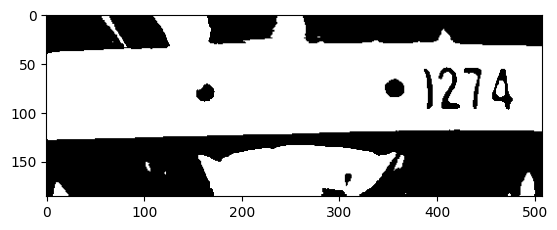

[([[np.int32(377), np.int32(47)],
   [np.int32(487), np.int32(47)],
   [np.int32(487), np.int32(107)],
   [np.int32(377), np.int32(107)]],
  '1274',
  np.float64(0.9773995876312256))]

In [31]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("./img.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Check your image filename or path.")

_, img_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(type(img_otsu), img_otsu.dtype, img_otsu.shape)  # Should be (height,width), dtype=uint8

plt.imshow(img_otsu, cmap='gray')
plt.show()
reader.readtext(img_otsu)


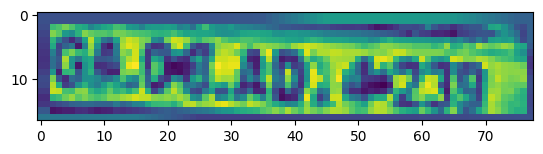

In [16]:
# Denoise
img = cv2.imread(original, cv2.IMREAD_GRAYSCALE)
# img = cv2.fastNlMeansDenoising(img, None, 30, 7, 21)
# Contrast (CLAHE)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
img = clahe.apply(img)
plt.imshow(img)


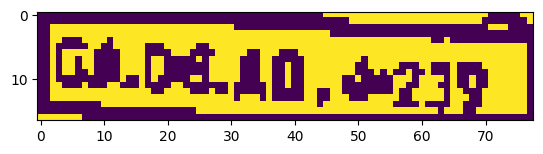

In [17]:
# Adaptive Gaussian
img = cv2.imread(original, cv2.IMREAD_GRAYSCALE)
img_adapt_gauss = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY, 11, 2)
plt.imshow(img_adapt_gauss)

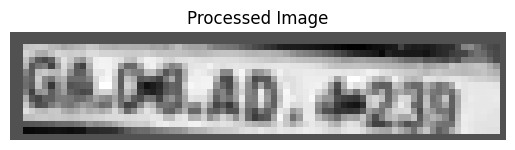

In [18]:
import cv2
import numpy as np

# Load the image (in grayscale for OCR preprocessing)
image = cv2.imread(original, cv2.IMREAD_GRAYSCALE)

# --- Step 1: Brighten the image ---
# Increase brightness by adding a constant to all pixels
bright = cv2.convertScaleAbs(image, alpha=1.0, beta=50)  # beta = brightness

# --- Step 2: Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) ---
# clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# clahe_img = clahe.apply(bright)

import matplotlib.pyplot as plt

plt.imshow(bright, cmap='gray')
plt.title('Processed Image')
plt.axis('off')
plt.show()

In [19]:
import cv2
import pytesseract

# Load and preprocess image
img = cv2.imread(original)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5,5), 0)
thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY, 11, 2)
resized = cv2.resize(thresh, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# OCR
text = pytesseract.image_to_string(resized)
print(text)


TesseractNotFoundError: tesseract is not installed or it's not in your PATH. See README file for more information.

In [41]:
import cv2
from PIL import Image
import pytesseract

# Load and preprocess image
img_path = './img.png'  # or `original`
image = cv2.imread(img_path)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# # Apply thresholding
# _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

# # Save temporary processed image for PIL to read
# cv2.imwrite('temp_ocr.png', thresh)

# Use pytesseract on processed image
img = Image.fromarray(gray)
text = pytesseract.image_to_string(img, lang='eng', config='--psm 11')
print("Extracted Text:\n", text)


Extracted Text:
 _— > eee

©9274

—

